In [22]:
# data tools and plotting

import logging
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

logging.getLogger("mlgflow.sklearn").setLevel(logging.ERROR)
#====================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Model from scikit-learn

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.model_selection import TunedThresholdClassifierCV, TimeSeriesSplit, RandomizedSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import PrecisionRecallDisplay

import mlflow
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000);
#==========================
class TSFE(BaseEstimator, TransformerMixin):
    def __init__(self, feature_cols,  feature_config):#, target_col='label1'):
        self.feature_cols = feature_cols
        #self.target_col = target_col
        self.feature_config = feature_config
    #==========
    def fit (self, X, y=None):
        return self
    #=============
    def _fill_Nan(self, df, feature_cols):
        
        df[feature_cols] = df[feature_cols].ffill().fillna(df[feature_cols].median()) # df[feature_cols].median()
        return df
    # ============
    def _ratio_featutre_gen(self, df, feature):
        
        df[f'{feature[0]}_{feature[1]}_ratio'] = df[feature[0]]/df[feature[1]]
        return df
    #===================
    def _diff_cross_gen(self, df, feature):
    
        df[f'{feature[0]}_{feature[1]}_diff_cross'] = df[feature[0]]-df[feature[1]]
        return df
    #=============
    def _multi_featutre_gen(self, df, feature):
        df[f'{feature[0]}_{feature[1]}_multi'] = df[feature[0]]*df[feature[1]]
        return df

    #=============== diff, lag, rolling
    def _diff_gen(self, df, feature, period):
        for p in period:
            df[f'{feature}_diff_{p}'] = (df[f'{feature}'].diff(p))#.fillna(df[f'{feature}_diff_{p}'].median())

        return df
    #===============
    def _lag_gen (self, df, feature, period):
        for p in period:
            df[f'{feature}_lag_{p}'] = (df[f'{feature}'].shift(p))#.fillna(df[f'{feature}_lag_{p}'].median())
        return df
    #===============
    def _per_change_feature_gen(self, df, feature):

        df[f'{feature[0]}_{feature[1]}_per_change'] = (df[feature[0]]/df[feature[1]]+1e-7)*100
        return df

    #===============
    def _rolling_std_gen (self, df, feature, period):
        for p in period:
            df[f'{feature}_roll_std_{p}'] = (df[f'{feature}'].rolling(window=p, closed='left').std())#.fillna(df[f'{feature}_roll_std_{p}'].median())# self not included, NAN->0
        return df

    #===============
    def _roll_mean_percent_res_gen(self, df, feature, period):
        for p in period:
            df[f'{feature}_roll_mean_{p}'] = df[f'{feature}'].rolling(window=p, closed='left').mean()#.fillna(df[f'{feature}_roll_mean_{p}'].median()) # self not included
            df[f'{feature}_residual_{p}'] = ((df[f'{feature}']- df[f'{feature}_roll_mean_{p}'])/(df[f'{feature}_roll_mean_{p}']+1e-7))*100 # self not included
        return df
    #================
    def _Zscore_res_gen(self, df, feature):
        df[f'{feature[0]}_{feature[3]}_zcore_res_gen'] = ((df[feature[0]]-df[feature[1]])/df[feature[2]]*1e-7)
        return df
    #=================
    def _log_gen (self, df, feature):
        df[f'{feature}_log'] = np.sign(df[f'{feature}'])*np.log1p(np.abs(df[f'{feature}']))#.fillna(df[f'{feature}_lag_{p}'].median())
        return df
    #===========
    def _relative_per_gen(self, df, feature, period):
        for p in period:
            df[f'{feature}_relative_per_{p}'] = (df[f'{feature}']-(df[f'{feature}'].rolling(window=p, closed='left').min()))/((df[f'{feature}'].rolling(window=p, closed='left').max())-(df[f'{feature}'].rolling(window=p, closed='left').min())+1e-7) #.fillna(df[f'{feature}_roll_std_{p}'].median())# self not included, NAN->0
        return df
    #=================
    def _per_rank_gen(self, df, feature, period):
        for p in period:
            df[f'{feature}_per_rank_{p}'] = df[f'{feature}'].rolling(window=p, closed='left').rank(pct=True)
        return df
    #=================
    def _feature_eng_apply(self, df, config):
        for opt, params in config.items():
            cols = params['cols']
           # period = params.get('period') or params.get('periods', 1) # period's value -> periods's -> 1

            for feature in cols:
                if opt == 'diff':
                    period = params.get('period') or params.get('periods', 1)
                    df = self._diff_gen(df, feature, period)
                elif opt == 'ratio':
                    df = self._ratio_featutre_gen(df, feature)
                elif opt == 'diff_cross':
                    df = self._diff_cross_gen(df, feature)
                elif opt == 'multi':
                    df = self._multi_featutre_gen(df, feature)
                elif opt == 'lag':
                    period = params.get('period') or params.get('periods', 1)
                    df = self._lag_gen(df, feature, period)
                elif opt == 'per_change':
                    df = self._per_change_feature_gen(df, feature)
                elif opt == 'roll_std':
                    period = params.get('period') or params.get('periods', 1)
                    df = self._rolling_std_gen( df, feature, period)
                elif opt == 'roll_mean_percent_res':
                    period = params.get('period') or params.get('periods', 1)
                    df = self._roll_mean_percent_res_gen(df, feature, period)
                elif opt == 'Z_score_res':
                    df = self._Zscore_res_gen(df, feature)
                elif opt == 'log':
                    df = self._log_gen(df, feature)
                elif opt  =='relative_per':
                    period = params.get('period') or params.get('periods', 1)
                    df = self._relative_per_gen(df, feature, period)
                elif opt == 'per_rank':
                    period = params.get('period') or params.get('periods', 1)
                    df = self._per_rank_gen(df, feature, period)

        return df 

    def transform(self, X):
        df = X.copy(deep=False)
        #df = self._fill_Nan(df, self.feature_cols)
        df = self._fill_Nan(df, self.feature_cols) # fill for original feature values
        #df = self._ratio_featutre_gen(df, self.feature_cols)
        df.index = pd.to_datetime(df.index)
        df = self._feature_eng_apply(df, self.feature_config)
        df = df.replace([np.inf, -np.inf], np.nan) # handle inf values, prevent Nan values
        df_columns = df.columns.tolist()
        df = self._fill_Nan(df, df_columns)

        floas_cols = df.select_dtypes(include=['float64']).columns
        df[floas_cols] = df[floas_cols].astype('float32')

        return df
    

#=====================

from sklearn.metrics import precision_recall_curve
def get_best_threshold(y_true, y_prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    p = precisions[:-1]
    r = recalls[:-1]

    f1_scores = 2 * (p * r) / (p + r + 1e-7) # 1e-7 to prevent Nan

    best_index = np.argmax(f1_scores)
    best_thres = thresholds[best_index]
    return best_thres, f1_scores[best_index], p[best_index], r[best_index]

#=========mlflow setting==========


mlflow.set_tracking_uri(
    "http://127.0.0.1:5000"
)


mlflow.set_experiment('isCnan_mhd')
#=============== feature engineering and define the needed features

feature_cols= [#'datetime', 
  #'tamb',  'pamb' ,
  #'psamp',
  
  'pflow', 'tmod',  'CH4_rt', 'CH4_w',
       'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time', 'CH4_end_time',
       'CH4_start_level', 'CH4_end_level', #'duration', 
       'is_air','is_std',
       #'previous_type_std', 'previous_type_air','next_type_std', 'next_type_air', 
       'last_std_ht', 'last_air_ht','level_rt_ratio',
       'rt_position',
    'baseline_slope',
    'level_area_ratio',
    'last_std_area',
'last_air_area',
'last_std_rt',
'last_air_rt',
'last_std_start_level',
'last_air_start_level',
       #'is_ht_zero_and_C_Nan','is_normal_std', 
       # #'is_bad_std', 'is_protential_flagged_air'
       ]



feature_config ={
    'diff':{'cols': ['CH4_area', 
                    'CH4_ht','CH4_rt','CH4_w' ,'tmod',#'CH4_end_time','CH4_start_time',
                ], 'periods':[1,2]},

    'lag':{'cols':['CH4_area', 'CH4_rt',  'CH4_ht', #'tmod',  'psamp','pamb','tamb',
                'pflow',
                'CH4_w','CH4_skew'], 'periods':[1,2]},

    

    'roll_std':{'cols': ['CH4_w', 'CH4_end_time','CH4_ht'], 'period':['1h','2h','1D','2D']},

    'roll_mean_percent_res':{'cols':['CH4_rt', 'CH4_start_time','CH4_skew' ,'CH4_end_time',
                             'CH4_w', 'CH4_ht'], 'period': ['1h','2h','1D','2D']},

    'diff_cross':{'cols':[['CH4_end_time', 'CH4_start_time'],
                          # ['CH4_w_roll_mean_2h', 'CH4_w_roll_mean_7h'],
                           ['last_std_ht', 'last_air_ht'],['CH4_end_level', 'CH4_start_level'],
                           ['CH4_ht', 'last_std_ht'], ['CH4_ht', 'last_air_ht'],#['CH4_ht', 'CH4_ht_lag_72'],['CH4_w', 'CH4_w_lag_72'],
                           ['pflow', 'pflow_lag_1'],['CH4_skew','CH4_skew_lag_1']
                           ]}, 

    'log':{'cols':['CH4_end_time', 'last_std_ht','last_air_ht']},

    'multi':{'cols':[['CH4_w', 'CH4_ht'],['CH4_end_time_CH4_start_time_diff_cross','last_std_ht_log'], ['CH4_end_time_CH4_start_time_diff_cross','last_air_ht_log']]},

    'ratio':{'cols':[   
                        ['CH4_area','CH4_w_CH4_ht_multi'], ['CH4_ht', 'CH4_area'],
                        ['CH4_w', 'CH4_end_time_CH4_start_time_diff_cross'],
                        ['CH4_rt', 'CH4_end_time_CH4_start_time_diff_cross'],

                        ['CH4_ht', 'last_air_ht'], ['CH4_ht', 'last_air_ht'],
                        #['CH4_w_roll_std_2h', 'CH4_w_roll_std_1D'],
                        ['last_std_ht', 'last_air_ht'],
                        ['CH4_start_level', 'CH4_end_level'],
                        ['CH4_area', 'last_std_area'],['CH4_rt', 'last_std_rt'],['CH4_start_level', 'last_std_start_level'],
                        
                        ['CH4_w_roll_std_2h', 'CH4_w_roll_mean_1h'], ['CH4_ht_roll_std_2h', 'CH4_ht_roll_mean_1h'],
                        ['CH4_w_roll_std_2h', 'CH4_w_roll_mean_2h'], ['CH4_ht_roll_std_2h', 'CH4_ht_roll_mean_2h'],
                       # ['CH4_w_roll_std_7h', 'CH4_w_roll_mean_7h'],['CH4_ht_roll_std_7h', 'CH4_ht_roll_mean_7h'],
                        ['CH4_w_roll_std_2D', 'CH4_w_roll_mean_2D'],['CH4_ht_roll_std_2D', 'CH4_ht_roll_mean_2D'],
                        
                       #['CH4_end_time', 'CH4_start_time'], ['CH4_area', 'pflow'],  ['CH4_skew', 'CH4_w'],['CH4_w', 'CH4_ht']
                       ]}, 


    'per_change':{'cols':[['CH4_ht_diff_1', 'CH4_ht_lag_1'],['last_std_ht', 'last_air_ht']]},
    #'relative_per': {'cols': ['CH4_w', 'CH4_end_time','CH4_ht'], 'period':['2h','7h']},
    #'Z_score_res':{'cols':[['CH4_w', 'CH4_w_roll_mean_2h', 'CH4_w_roll_std_2h', '2h'], #['CH4_end_time', 'CH4_end_time_roll_mean_7D', 'CH4_end_time_roll_std_7D', '7D']
                           #]},
    #'per_rank': {'cols': ['CH4_w', 'CH4_skew','CH4_ht'], 'period':['7h','7D','30D']},


}

In [23]:
#================ data reading and preprocessing=========
df = pd.read_csv('../data/processed/mhd_ch4_cnan_v1.csv', index_col= 'datetime')
df = df.drop(df[df['year']==2026].index)

df.columns.tolist()

df['only_std_ht'] = df['CH4_ht'].where(df['type'] == 'std')
std_median = df.loc[df['type']=='std', 'CH4_ht'].median()

df['last_std_ht'] = df['only_std_ht'].ffill().shift(1).fillna(std_median)
#======== air
df['only_air_ht'] = df['CH4_ht'].where(df['type'] == 'air')
air_median = df.loc[df['type']=='air', 'CH4_ht'].median()
df['last_air_ht'] = df['only_air_ht'].ffill().shift(1).fillna(air_median)
#df['is_CH4_w_nan'] = df['CH4_w'].isna().astype(int) 
#=====================
df['next_std_ht'] = df['only_std_ht'].bfill().shift(-1).fillna(std_median)

std_median = df.loc[df['type']=='std', 'CH4_ht'].median()
df['next_air_ht'] = df['only_air_ht'].bfill().shift(-1).fillna(air_median)
#=================== area
df['only_std_area'] = df['CH4_area'].where(df['type'] == 'std')
std_median = df.loc[df['type']=='std', 'CH4_area'].median()

df['last_std_area'] = df['only_std_area'].ffill().shift(1).fillna(std_median)
#======== air
df['only_air_area'] = df['CH4_area'].where(df['type'] == 'air')
air_median = df.loc[df['type']=='air', 'CH4_area'].median()
df['last_air_area'] = df['only_air_area'].ffill().shift(1).fillna(air_median)
#df['is_CH4_w_nan'] = df['CH4_w'].isna().astype(int) 
#============= rt
df['only_std_rt'] = df['CH4_rt'].where(df['type'] == 'std')
std_median = df.loc[df['type']=='std', 'CH4_rt'].median()

df['last_std_rt'] = df['only_std_rt'].ffill().shift(1).fillna(std_median)
#========rt
df['only_air_rt'] = df['CH4_rt'].where(df['type'] == 'air')
air_median = df.loc[df['type']=='air', 'CH4_rt'].median()
df['last_air_rt'] = df['only_air_rt'].ffill().shift(1).fillna(air_median)


#==========================start level
df['only_std_start_level'] = df['CH4_start_level'].where(df['type'] == 'std')
std_median = df.loc[df['type']=='std', 'CH4_start_level'].median()

df['last_std_start_level'] = df['only_std_start_level'].ffill().shift(1).fillna(std_median)
#========rt
df['only_air_start_level'] = df['CH4_start_level'].where(df['type'] == 'air')
air_median = df.loc[df['type']=='air', 'CH4_start_level'].median()
df['last_air_start_level'] = df['only_air_start_level'].ffill().shift(1).fillna(air_median)

#=============
#df['is_CH4_w_nan'] = df['CH4_w'].isna().astype(int) 
df['level_rt_ratio'] = (df['CH4_end_time'] -df['CH4_start_time'])/df['CH4_rt']
df['rt_position'] = (df['CH4_rt'] - df['CH4_start_time']) / df['CH4_w']
df['baseline_slope'] =(df['CH4_end_level'] -df['CH4_start_level'])/df['CH4_w']
df['level_area_ratio'] = np.maximum(df['CH4_end_level'],df['CH4_start_level'] )/(df['CH4_area']+1e-7)

In [24]:
df.columns

Index(['date', 'time', 'type', 'sample', 'standard', 'port', 'ht', 'tmod',
       'tamb', 'lab_temp', 'pflow', 'psamp', 'ploop', 'pamb', 'CH4_rt',
       'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time',
       'CH4_end_time', 'CH4_start_level', 'CH4_end_level', 'CH4_Rl_ht',
       'CH4_Rl_a', 'CH4_Rl', 'CH4_norm_ht', 'CH4_norm_a', 'CH4_norm_w',
       'CH4_R_ht', 'CH4_R_a', 'CH4_R', 'CH4_C_ht', 'CH4_C_a', 'CH4_C',
       'CH4_std_stdev', 'CH4_std_rep', 'CH4_Cstd', 'CH4_flag_ht', 'CH4_flag_a',
       'CH4_flag', 'CH4_flag_p', 'CH4_flag_ht_bin', 'CH4_flag_a_bin', 'label1',
       'datetime_str', 'is_ht_999', 'is_area_999', 'is_rt_zero', 'is_w_zero',
       'duration', 'is_duration_spike', 'baseline_drift', 'ht_area_ratio',
       'last_std_time', 'seconds_since_last_std', 'type_std', 'type_air',
       'type_tank', 'type_blank', 'type_cal', 'type_other', 'year', 'month',
       'day', 'hour', 'minute', 'seconds', 'is_air', 'is_std', 'label_c_nan',
       'only_std_ht', 'last_

In [25]:
X = df[feature_cols]
y = df['label_c_nan']
split_idx = int(len(df)*0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


tscv = TimeSeriesSplit(n_splits=5)
print(X.columns)
X_train.head()

Index(['pflow', 'tmod', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew',
       'CH4_start_time', 'CH4_end_time', 'CH4_start_level', 'CH4_end_level',
       'is_air', 'is_std', 'last_std_ht', 'last_air_ht', 'level_rt_ratio',
       'rt_position', 'baseline_slope', 'level_area_ratio', 'last_std_area',
       'last_air_area', 'last_std_rt', 'last_air_rt', 'last_std_start_level',
       'last_air_start_level'],
      dtype='object')


,pflow,tmod,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,is_air,is_std,last_std_ht,last_air_ht,level_rt_ratio,rt_position,baseline_slope,level_area_ratio,last_std_area,last_air_area,last_std_rt,last_air_rt,last_std_start_level,last_air_start_level
datetime,,,,,,,,,,,,,,,,,,,,,,,,,
1994-02-16 14:29:00,841.9,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0,151205.0,152438.5,NaN,NaN,NaN,0.000000,1349499.0,1375336.0,98.6,98.6,24223.0,24253.0
1994-02-16 14:49:00,840.4,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0,151205.0,0.0,NaN,NaN,NaN,0.000000,1349499.0,0.0,98.6,0.0,24223.0,0.0
1994-02-16 15:09:00,839.4,40.01,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,1,0,151205.0,0.0,0.304189,3.000000,-13.076923,0.020270,1349499.0,0.0,98.6,0.0,24223.0,0.0
1994-02-16 15:29:00,839.6,40.00,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,1,0,151205.0,190908.0,0.451477,1.255474,0.000000,0.093809,1349499.0,496440.0,98.6,109.8,24223.0,10063.0
1994-02-16 18:00:00,845.4,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0,151205.0,151667.0,NaN,NaN,NaN,0.000000,1349499.0,1065982.0,98.6,94.8,24223.0,99999.0


In [26]:
import shap
tsfe = TSFE(feature_cols=feature_cols, feature_config=feature_config)

X_train_final = tsfe.fit_transform(X_train)
y_train_final = y_train.copy()
print(X_train_final.columns)
#X_train_final = X_train_final[feature_ml]

pipe_rnd = Pipeline([
    #('scl', StandardScaler()),
    ('clf', RandomForestClassifier())
])

param_grid = {
    'clf__n_estimators': [100],
    'clf__max_depth': [8],
    'clf__min_samples_leaf':[20, 50],
    'clf__random_state':[42],
    'clf__max_features':[0.6],
    'clf__n_jobs':[-1],
    'clf__class_weight':['balanced']
}

/tmp/ipykernel_1589/945177716.py:95: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{feature}_residual_{p}'] = ((df[f'{feature}']- df[f'{feature}_roll_mean_{p}'])/(df[f'{feature}_roll_mean_{p}']+1e-7))*100 # self not included
/tmp/ipykernel_1589/945177716.py:94: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{feature}_roll_mean_{p}'] = df[f'{feature}'].rolling(window=p, closed='left').mean()#.fillna(df[f'{feature}_roll_mean_{p}'].median()) # self not included
/tmp/ipykernel_1589/945177716.py:95: PerformanceWarning: DataF

Index(['pflow', 'tmod', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew',
       'CH4_start_time', 'CH4_end_time', 'CH4_start_level',
       ...
       'CH4_rt_last_std_rt_ratio',
       'CH4_start_level_last_std_start_level_ratio',
       'CH4_w_roll_std_2h_CH4_w_roll_mean_1h_ratio',
       'CH4_ht_roll_std_2h_CH4_ht_roll_mean_1h_ratio',
       'CH4_w_roll_std_2h_CH4_w_roll_mean_2h_ratio',
       'CH4_ht_roll_std_2h_CH4_ht_roll_mean_2h_ratio',
       'CH4_w_roll_std_2D_CH4_w_roll_mean_2D_ratio',
       'CH4_ht_roll_std_2D_CH4_ht_roll_mean_2D_ratio',
       'CH4_ht_diff_1_CH4_ht_lag_1_per_change',
       'last_std_ht_last_air_ht_per_change'],
      dtype='object', length=138)


In [27]:
X_train_final.columns.to_list()

['pflow',
 'tmod',
 'CH4_rt',
 'CH4_w',
 'CH4_ht',
 'CH4_area',
 'CH4_skew',
 'CH4_start_time',
 'CH4_end_time',
 'CH4_start_level',
 'CH4_end_level',
 'is_air',
 'is_std',
 'last_std_ht',
 'last_air_ht',
 'level_rt_ratio',
 'rt_position',
 'baseline_slope',
 'level_area_ratio',
 'last_std_area',
 'last_air_area',
 'last_std_rt',
 'last_air_rt',
 'last_std_start_level',
 'last_air_start_level',
 'CH4_area_diff_1',
 'CH4_area_diff_2',
 'CH4_ht_diff_1',
 'CH4_ht_diff_2',
 'CH4_rt_diff_1',
 'CH4_rt_diff_2',
 'CH4_w_diff_1',
 'CH4_w_diff_2',
 'tmod_diff_1',
 'tmod_diff_2',
 'CH4_area_lag_1',
 'CH4_area_lag_2',
 'CH4_rt_lag_1',
 'CH4_rt_lag_2',
 'CH4_ht_lag_1',
 'CH4_ht_lag_2',
 'pflow_lag_1',
 'pflow_lag_2',
 'CH4_w_lag_1',
 'CH4_w_lag_2',
 'CH4_skew_lag_1',
 'CH4_skew_lag_2',
 'CH4_w_roll_std_1h',
 'CH4_w_roll_std_2h',
 'CH4_w_roll_std_1D',
 'CH4_w_roll_std_2D',
 'CH4_end_time_roll_std_1h',
 'CH4_end_time_roll_std_2h',
 'CH4_end_time_roll_std_1D',
 'CH4_end_time_roll_std_2D',
 'CH4_ht_rol

In [28]:
X_train_final['CH4_w_CH4_end_time_CH4_start_time_diff_cross_ratio'].head(20)

datetime
1994-02-16 14:29:00    0.143774
1994-02-16 14:49:00    0.143774
1994-02-16 15:09:00    0.077844
1994-02-16 15:29:00    0.160047
1994-02-16 18:00:00    0.160047
1994-02-16 18:20:00    0.160047
1994-02-16 18:40:00    0.160047
1994-02-16 19:00:00    0.160047
1994-02-16 19:20:00    0.160047
1994-02-16 19:40:00    0.160047
1994-02-16 20:23:00    0.160047
1994-02-16 20:43:00    0.160047
1994-02-16 21:03:00    0.160047
1994-02-16 21:24:00    0.160047
1994-02-16 21:44:00    0.160047
1994-02-16 22:04:00    0.160047
1994-02-16 22:24:00    0.160047
1994-02-16 22:44:00    0.160047
1994-02-16 23:04:00    0.160047
1994-02-16 23:24:00    0.160047
Name: CH4_w_CH4_end_time_CH4_start_time_diff_cross_ratio, dtype: float32

In [29]:
X_train_final.head(10)

,pflow,tmod,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,is_air,is_std,last_std_ht,last_air_ht,level_rt_ratio,rt_position,baseline_slope,level_area_ratio,last_std_area,last_air_area,last_std_rt,last_air_rt,last_std_start_level,last_air_start_level,CH4_area_diff_1,CH4_area_diff_2,CH4_ht_diff_1,CH4_ht_diff_2,CH4_rt_diff_1,CH4_rt_diff_2,CH4_w_diff_1,CH4_w_diff_2,tmod_diff_1,tmod_diff_2,CH4_area_lag_1,CH4_area_lag_2,CH4_rt_lag_1,CH4_rt_lag_2,CH4_ht_lag_1,CH4_ht_lag_2,pflow_lag_1,pflow_lag_2,CH4_w_lag_1,CH4_w_lag_2,CH4_skew_lag_1,CH4_skew_lag_2,CH4_w_roll_std_1h,CH4_w_roll_std_2h,CH4_w_roll_std_1D,CH4_w_roll_std_2D,CH4_end_time_roll_std_1h,CH4_end_time_roll_std_2h,CH4_end_time_roll_std_1D,CH4_end_time_roll_std_2D,CH4_ht_roll_std_1h,CH4_ht_roll_std_2h,CH4_ht_roll_std_1D,CH4_ht_roll_std_2D,CH4_rt_roll_mean_1h,CH4_rt_residual_1h,CH4_rt_roll_mean_2h,CH4_rt_residual_2h,CH4_rt_roll_mean_1D,CH4_rt_residual_1D,CH4_rt_roll_mean_2D,CH4_rt_residual_2D,CH4_start_time_roll_mean_1h,CH4_start_time_residual_1h,CH4_start_time_roll_mean_2h,CH4_start_time_residual_2h,CH4_start_time_roll_mean_1D,CH4_start_time_residual_1D,CH4_start_time_roll_mean_2D,CH4_start_time_residual_2D,CH4_skew_roll_mean_1h,CH4_skew_residual_1h,CH4_skew_roll_mean_2h,CH4_skew_residual_2h,CH4_skew_roll_mean_1D,CH4_skew_residual_1D,CH4_skew_roll_mean_2D,CH4_skew_residual_2D,CH4_end_time_roll_mean_1h,CH4_end_time_residual_1h,CH4_end_time_roll_mean_2h,CH4_end_time_residual_2h,CH4_end_time_roll_mean_1D,CH4_end_time_residual_1D,CH4_end_time_roll_mean_2D,CH4_end_time_residual_2D,CH4_w_roll_mean_1h,CH4_w_residual_1h,CH4_w_roll_mean_2h,CH4_w_residual_2h,CH4_w_roll_mean_1D,CH4_w_residual_1D,CH4_w_roll_mean_2D,CH4_w_residual_2D,CH4_ht_roll_mean_1h,CH4_ht_residual_1h,CH4_ht_roll_mean_2h,CH4_ht_residual_2h,CH4_ht_roll_mean_1D,CH4_ht_residual_1D,CH4_ht_roll_mean_2D,CH4_ht_residual_2D,CH4_end_time_CH4_start_time_diff_cross,last_std_ht_last_air_ht_diff_cross,CH4_end_level_CH4_start_level_diff_cross,CH4_ht_last_std_ht_diff_cross,CH4_ht_last_air_ht_diff_cross,pflow_pflow_lag_1_diff_cross,CH4_skew_CH4_skew_lag_1_diff_cross,CH4_end_time_log,last_std_ht_log,last_air_ht_log,CH4_w_CH4_ht_multi,CH4_end_time_CH4_start_time_diff_cross_last_std_ht_log_multi,CH4_end_time_CH4_start_time_diff_cross_last_air_ht_log_multi,CH4_area_CH4_w_CH4_ht_multi_ratio,CH4_ht_CH4_area_ratio,CH4_w_CH4_end_time_CH4_start_time_diff_cross_ratio,CH4_rt_CH4_end_time_CH4_start_time_diff_cross_ratio,CH4_ht_last_air_ht_ratio,last_std_ht_last_air_ht_ratio,CH4_start_level_CH4_end_level_ratio,CH4_area_last_std_area_ratio,CH4_rt_last_std_rt_ratio,CH4_start_level_last_std_start_level_ratio,CH4_w_roll_std_2h_CH4_w_roll_mean_1h_ratio,CH4_ht_roll_std_2h_CH4_ht_roll_mean_1h_ratio,CH4_w_roll_std_2h_CH4_w_roll_mean_2h_ratio,CH4_ht_roll_std_2h_CH4_ht_roll_mean_2h_ratio,CH4_w_roll_std_2D_CH4_w_roll_mean_2D_ratio,CH4_ht_roll_std_2D_CH4_ht_roll_mean_2D_ratio,CH4_ht_diff_1_CH4_ht_lag_1_per_change,last_std_ht_last_air_ht_per_change
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1994-02-16 14:29:00,841.900024,40.000000,0.000000,0.00,0.0,0.0,0.00,0.000000,0.000000,0.0,0.0,1,0,151205.0,152438.5,0.544699,1.775701,20.822943,0.000000,1349499.0,1375336.0,98.599998,98.599998,24223.0,24253.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.00,0.00,0.00,0.00,1334690.0,1334690.5,98.800003,98.800003,149085.0,149085.0,810.000000,810.000000,8.01,8.01,1.07,1.07,0.010000,0.010488,0.015855,0.018224,0.230940,0.273252,0.341777,0.354440,980.918640,1009.127563,1422.348389,1763.684570,98.800003,0.000000e+00,98.800003,0.000000e+00,98.650703,1.124638e-02,98.494217,2.095181e-02,84.800003,0.000000e+00,84.800003,0.000000e+00,84.665718,1.673080e-02,84.526436,2.727844e-02,1.073333,0.000000e+00,1.0725,0.000000e+00,1.069074,0.000000e+00,1.068273,4.598909e-02,139.699997,0.000000e+00,139.699997,0.000000e+00,139.654282,1.676165e-02,139.626160,2.79

Best hyparameter set 5-fold mean training AP: 0.72971
Best hyparameter set 5- fold mean validation set: 0.57237


/tmp/ipykernel_1589/945177716.py:95: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{feature}_residual_{p}'] = ((df[f'{feature}']- df[f'{feature}_roll_mean_{p}'])/(df[f'{feature}_roll_mean_{p}']+1e-7))*100 # self not included
/tmp/ipykernel_1589/945177716.py:94: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{feature}_roll_mean_{p}'] = df[f'{feature}'].rolling(window=p, closed='left').mean()#.fillna(df[f'{feature}_roll_mean_{p}'].median()) # self not included
/tmp/ipykernel_1589/945177716.py:95: PerformanceWarning: DataF

====Evaluation report best threshold ===
Best threshold:0.6891
Best F1-score:0.5745; Best Precision:0.6360, Recall:0.5238
              precision    recall  f1-score   support

           0       0.93      0.96      0.95    136131
           1       0.64      0.52      0.57     19315

    accuracy                           0.90    155446
   macro avg       0.79      0.74      0.76    155446
weighted avg       0.90      0.90      0.90    155446



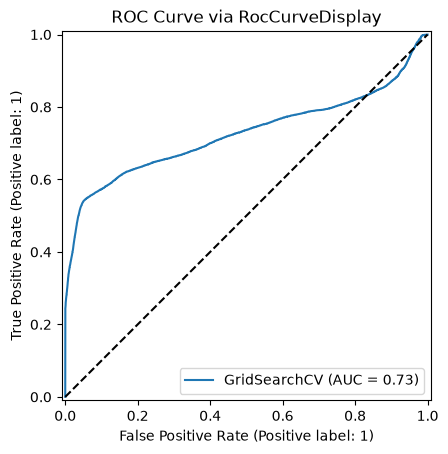

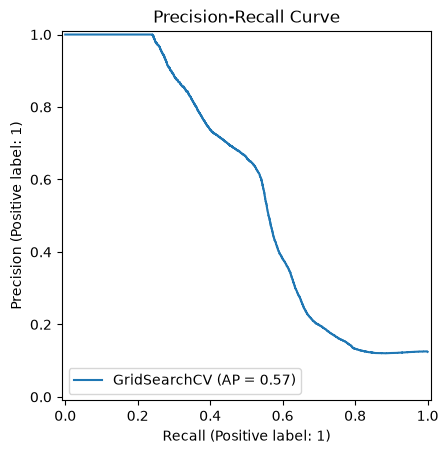

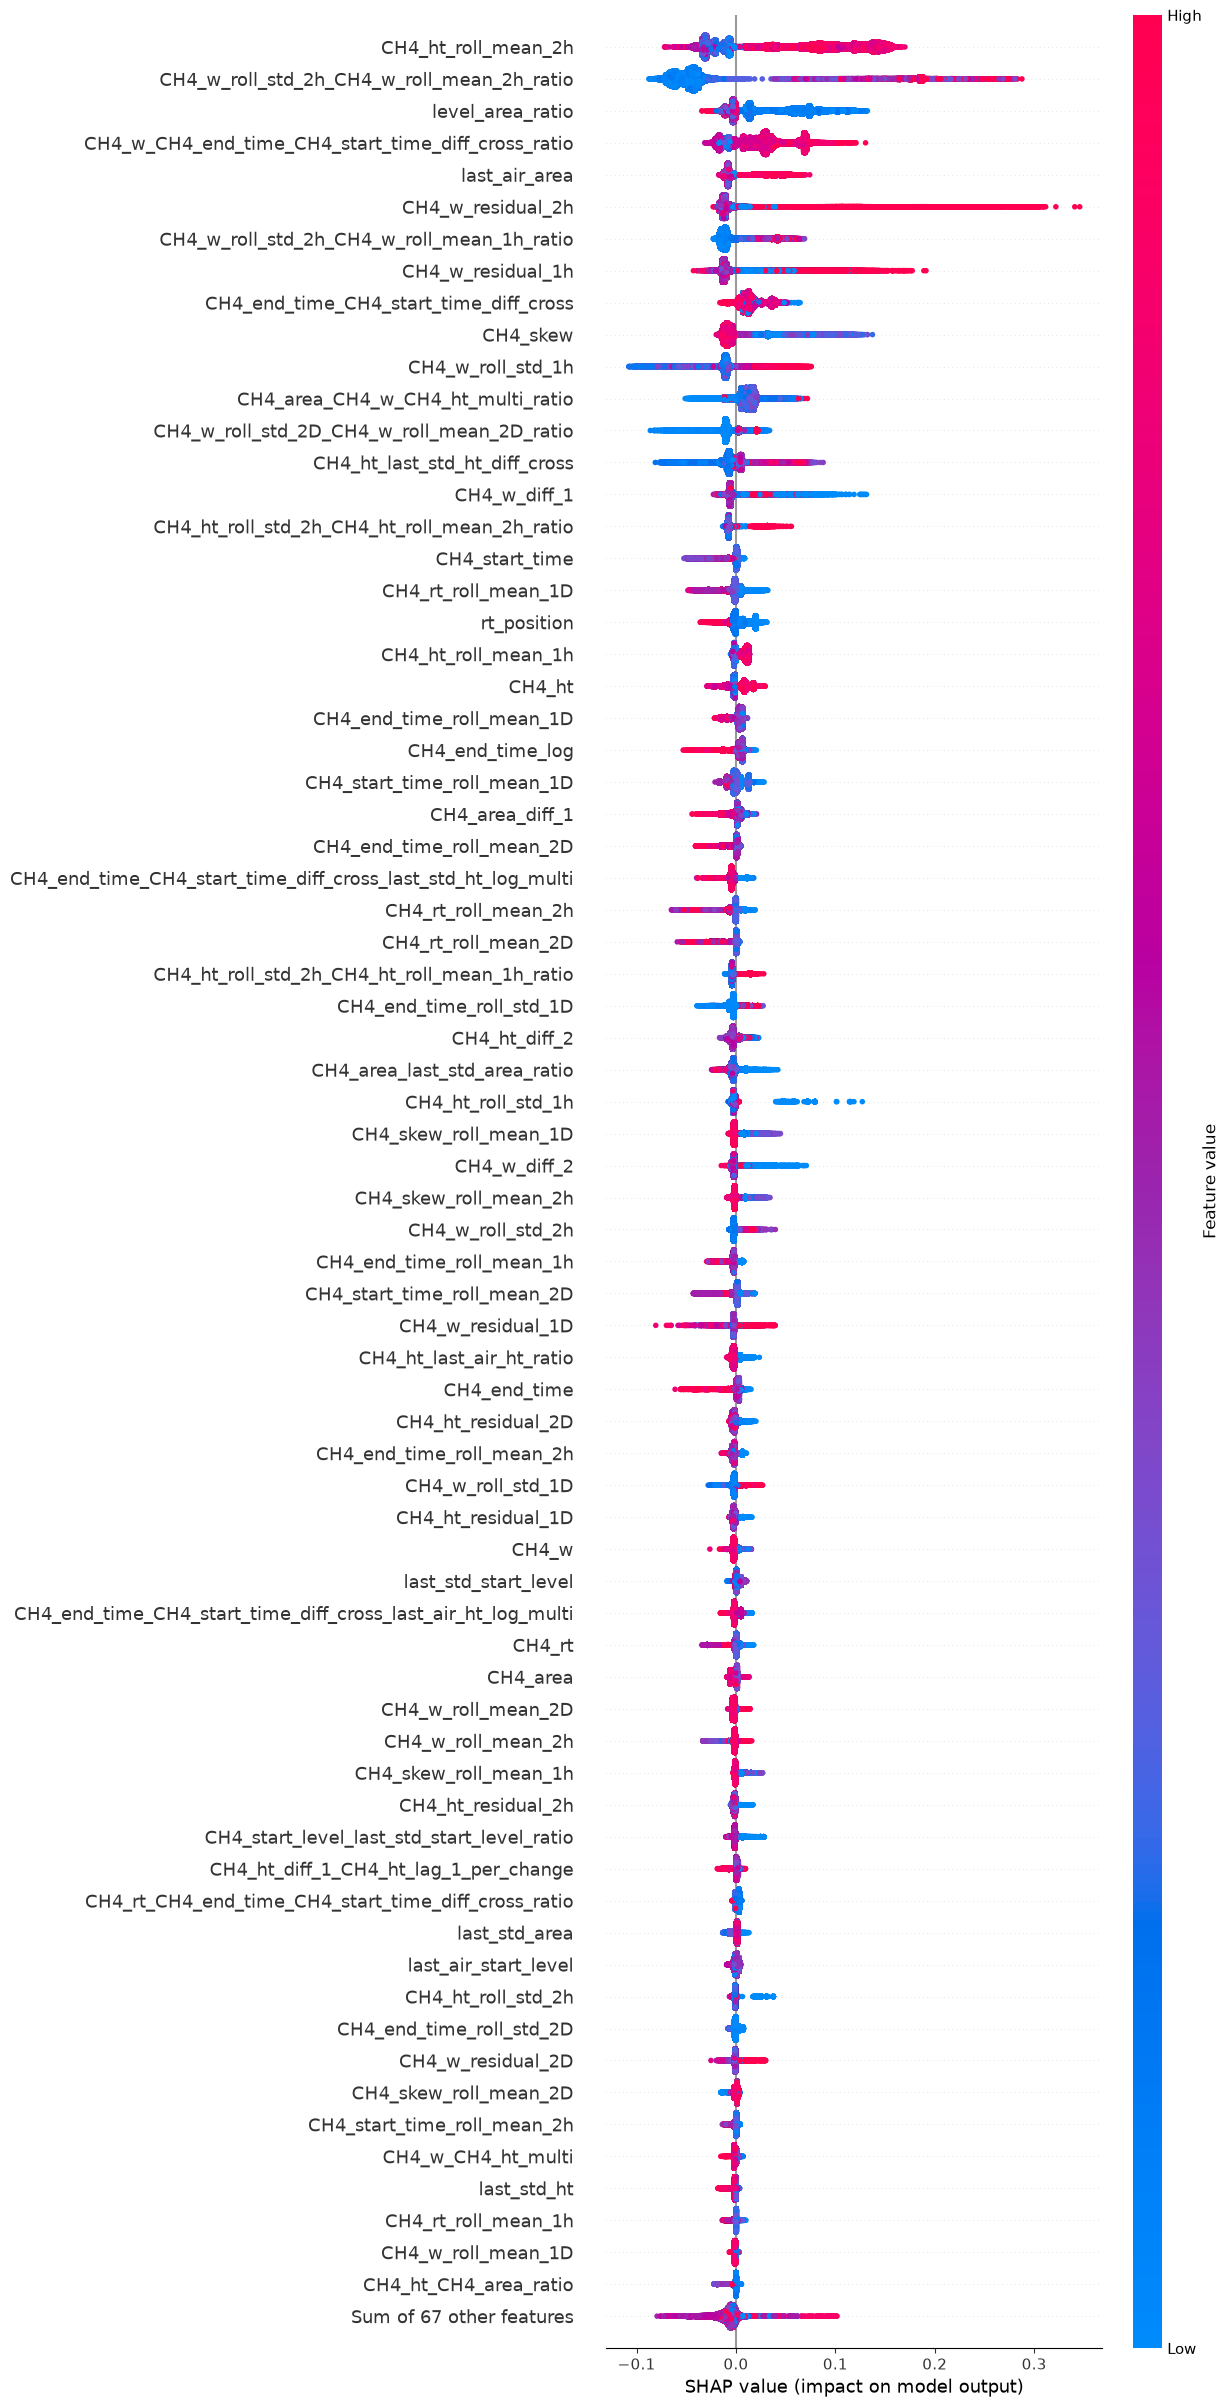

<Figure size 640x480 with 0 Axes>

🏃 View run RF_GridSearch_0719_v2 at: http://127.0.0.1:5000/#/experiments/7/runs/2d50becda8624b18afda801b7b64b68b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7
All Done!


In [30]:
with mlflow.start_run(run_name="RF_GridSearch_0719_v2") as parent_run:
    dataset_metadat={
        'feature_cols': feature_cols,
        'feature_config': feature_config
    }
    mlflow.log_dict(dataset_metadat, 'feature_config.json')
    
    grid = GridSearchCV(estimator=pipe_rnd, param_grid = param_grid, cv=tscv,  scoring='average_precision', n_jobs=4, return_train_score=True)
    grid.fit(X_train_final, y_train_final)

    # print best model score
    cv_results = pd.DataFrame(grid.cv_results_)
    best_index = grid.best_index_
    mean_train = cv_results.loc[best_index, 'mean_train_score']
    mean_test = cv_results.loc[best_index, 'mean_test_score']

    print(f"Best hyparameter set 5-fold mean training AP: {mean_train:.5f}")
    print(f"Best hyparameter set 5- fold mean validation set: {mean_test:.5f}")

        
    X_test_final = tsfe.fit_transform(X_test)
    y_test_final = y_test.copy()
    #X_test_final = X_test_final[feature_ml]
    #=========== Evaluation Report
    y_prob = grid.predict_proba(X_test_final)[:, 1]
    best_threshold, best_f1, best_prec, best_rec = get_best_threshold(y_test_final, y_prob)
    y_proba_best = (y_prob >= best_threshold).astype(int)

    print("====Evaluation report best threshold ===")
    print(f'Best threshold:{best_threshold:.4f}')
    print(f'Best F1-score:{best_f1:.4f}; Best Precision:{best_prec:.4f}, Recall:{best_rec:.4f}')
    print(classification_report(y_test_final, y_proba_best))
    #=========== plotting
    #======== ROC
    RocCurveDisplay.from_estimator(grid, X_test_final, y_test_final)
    
    plt.title("ROC Curve via RocCurveDisplay")
    plt.plot([0, 1], [0,1], 'k--') 
    plt.savefig("image/ROC_Curve.png")
    mlflow.log_artifact("image/ROC_Curve.png")
    plt.show()    
    plt.close()
    # ======= PRC 
    PrecisionRecallDisplay.from_estimator(grid, X_test_final, y_test_final)

    plt.title("Precision-Recall Curve")
    plt.savefig("image/PRC_Curve.png")
    mlflow.log_artifact("image/PRC_Curve.png")
    plt.show()    
    plt.close()
    #========= SHAP
    best_pipeline = grid.best_estimator_
    final_rf_model = best_pipeline.named_steps['clf']


    explainer = shap.TreeExplainer(final_rf_model)
    shap_values = explainer(X_test_final)

    shap.plots.beeswarm(shap_values[:, :, 1], max_display=72)
    plt.savefig("image/shap_summary.png")
    mlflow.log_artifact("image/shap_summary.png")
    plt.show()    
    plt.close()


print("All Done!")
    



In [13]:
shap_values_pos = shap_values[:,:, 1]
mean_shap_values = np.abs(shap_values_pos.values).mean(axis=0)

df_shap = pd.DataFrame({
    'fn':shap_values_pos .feature_names,
    'shap_imp':mean_shap_values
}).sort_values(by='shap_imp', ascending=False)

top_20 = df_shap['fn'].head(20).tolist()
print(top_20)

['CH4_w_roll_std_2h_CH4_w_roll_mean_2h_ratio', 'CH4_ht_roll_mean_2h', 'CH4_w_CH4_end_time_CH4_start_time_diff_cross_ratio', 'CH4_w_roll_std_7h_CH4_w_roll_mean_7h_ratio', 'CH4_area_CH4_w_CH4_ht_multi_ratio', 'CH4_ht_last_std_ht_diff_cross', 'CH4_w_diff_1', 'CH4_w_residual_7h', 'CH4_end_time_CH4_start_time_diff_cross', 'CH4_skew', 'CH4_ht_roll_mean_7h', 'CH4_end_time_CH4_start_time_diff_cross_last_std_ht_log_multi', 'CH4_start_level', 'CH4_w_residual_2h_log', 'CH4_w_roll_std_2h', 'last_air_ht', 'CH4_rt', 'CH4_w_residual_2h', 'CH4_area_diff_1', 'CH4_ht_roll_std_2h_CH4_ht_roll_mean_2h_ratio']


In [ ]:
feature_ml = ['CH4_w_roll_std_2h_CH4_w_roll_mean_2h_ratio', 
              'CH4_ht_roll_mean_2h', 
              'CH4_w_CH4_end_time_CH4_start_time_diff_cross_ratio', 
              'CH4_w_roll_std_7h_CH4_w_roll_mean_7h_ratio', 
              'CH4_area_CH4_w_CH4_ht_multi_ratio', 
              'CH4_ht_last_std_ht_diff_cross', 'CH4_w_diff_1', 
              
              'CH4_w_residual_7h', 
              'CH4_end_time_CH4_start_time_diff_cross', 
              'CH4_skew', 'CH4_ht_roll_mean_7h', 
              'CH4_end_time_CH4_start_time_diff_cross_last_std_ht_log_multi',  
              'CH4_w_residual_2h_log', 'CH4_w_roll_std_2h',
               'last_air_ht', 
              'CH4_rt', 'CH4_w_residual_2h',
               'CH4_area_diff_1', 
              'CH4_ht_roll_std_2h_CH4_ht_roll_mean_2h_ratio',
              
              'CH4_ht_CH4_ht_lag_72_diff_cross', 'CH4_w_CH4_w_lag_72_diff_cross',
       'pflow_pflow_lag_504_diff_cross',]

In [42]:
X_train_final.columns

Index(['pflow', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area', 'CH4_skew',
       'CH4_start_time', 'CH4_end_time', 'CH4_start_level', 'CH4_end_level',
       'last_std_ht', 'last_air_ht', 'CH4_ht_diff_1', 'CH4_ht_diff_2',
       'CH4_area_lag_1', 'CH4_area_lag_2', 'CH4_rt_lag_1', 'CH4_rt_lag_2',
       'CH4_ht_lag_1', 'CH4_ht_lag_2', 'CH4_skew_lag_1', 'CH4_skew_lag_2',
       'CH4_w_roll_std_2h', 'CH4_w_roll_std_7h', 'CH4_w_roll_std_12h',
       'CH4_w_roll_std_19h', 'CH4_w_roll_std_1D', 'CH4_w_roll_std_2D',
       'CH4_end_time_roll_std_2h', 'CH4_end_time_roll_std_7h',
       'CH4_end_time_roll_std_12h', 'CH4_end_time_roll_std_19h',
       'CH4_end_time_roll_std_1D', 'CH4_end_time_roll_std_2D',
       'CH4_w_roll_mean_2h', 'CH4_w_residual_2h', 'CH4_w_roll_mean_7h',
       'CH4_w_residual_7h', 'CH4_w_roll_mean_12h', 'CH4_w_residual_12h',
       'CH4_w_roll_mean_19h', 'CH4_w_residual_19h', 'CH4_w_roll_mean_1D',
       'CH4_w_residual_1D', 'CH4_w_roll_mean_2D', 'CH4_w_residual_2D',
       'CH

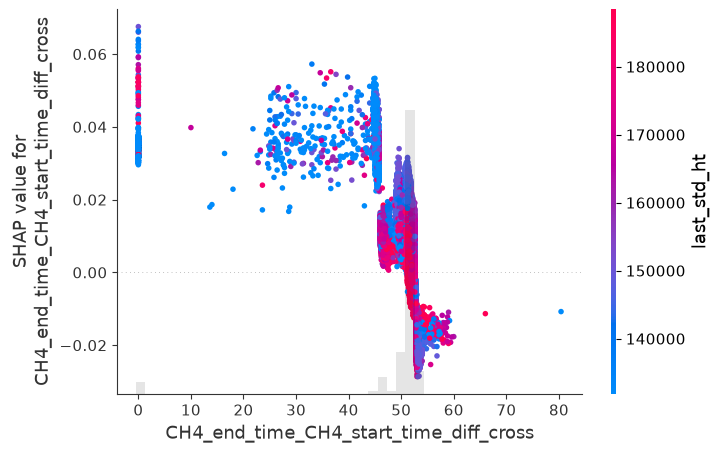

In [33]:
shap.plots.scatter(
    shap_values[:, 'CH4_end_time_CH4_start_time_diff_cross', 1],
    color=shap_values[:, :, 1]
)

In [10]:
grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](78,)","['pflow','CH4_rt','CH4_w',...,'CH4_ht_diff_1_CH4_ht_lag_1_per_change', 'CH4_w_7D_zcore_res_gen','CH4_w_residual_2h_log']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,78
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2


In [67]:
y_prob = grid.best_estimator_.predict_proba(X_test_final)[:, 1]
best_threshold, best_f1, best_prec, best_rec = get_best_threshold(y_test_final, y_prob)
y_proba_best = (y_prob >= best_threshold).astype(int)

print("====Evaluation report best threshold ===")
print(f'Best threshold:{best_threshold:.4f}')
print(f'Best F1-score:{best_f1:.4f}; Best Precision:{best_prec:.4f}, Recall:{best_rec:.4f}')
print(classification_report(y_test_final, y_proba_best))

====Evaluation report best threshold ===
Best threshold:0.5463
Best F1-score:0.6229; Best Precision:0.5106, Recall:0.7983
              precision    recall  f1-score   support

           0       0.97      0.89      0.93    136131
           1       0.51      0.80      0.62     19315

    accuracy                           0.88    155446
   macro avg       0.74      0.84      0.78    155446
weighted avg       0.91      0.88      0.89    155446

